In [7]:
import sys
print(sys.executable)

/users/kdm/khansa/.local/share/mamba/envs/geo_env/bin/python


In [6]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
import folium
import json
import matplotlib.pyplot as plt
from shapely.geometry import box
from rasterio.windows import from_bounds
from rasterio.plot import show
import random
from shapely.geometry import box
import osmnx as ox
import os
import os
import requests
import shutil
from PIL import Image, ImageFile
from geojson import Feature, FeatureCollection  # Add this import
import math
import torch
import transformers
import fiona
print("Fiona drivers GPKG available?", "GPKG" in fiona.supported_drivers)
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import least_squares
from scipy.ndimage import median_filter

ModuleNotFoundError: No module named 'geojson'

## Affine rectification

### Black


AFFINE RECTIFICATION: 16_279.jpg
Scenario: Façade parallel to camera, tilt=25.0°

Image: 640×640 pixels
Mask: loaded
[DEBUG] Running LSD line detector...
  ✓ Detected 1118 lines


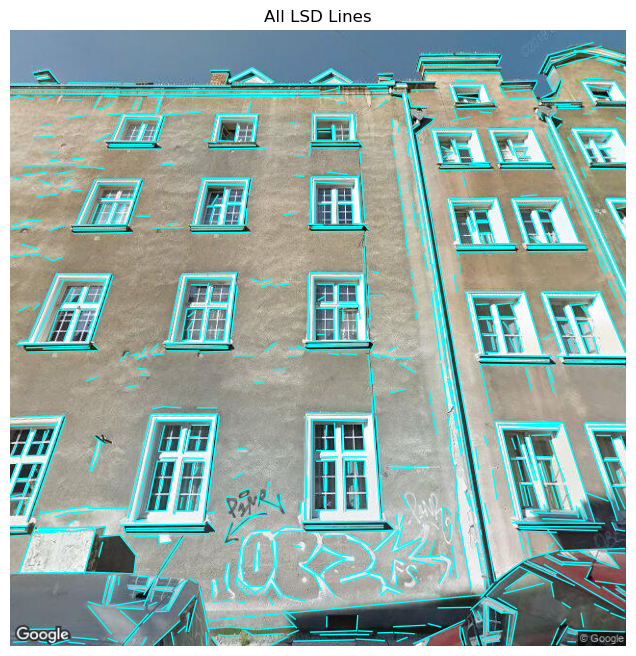


VERTICAL VP DETECTION
Vertical lines: 111
  RANSAC: 111 lines, threshold=10.0°
  ✓ VP: (325.7, -414.8)
  ✓ Inliers: 110/111

HORIZONTAL VP DETECTION
Horizontal lines: 163
  RANSAC: 163 lines, threshold=10.0°
  ✓ VP: (38881.4, 94.8)
  ✓ Inliers: 156/163
  ✓ Horizontal VP very far (60.3×width) → At infinity


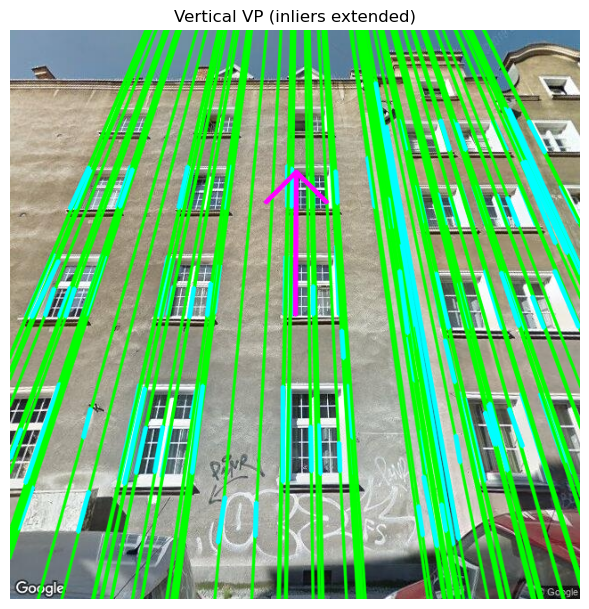


COMPUTING 4-POINT HOMOGRAPHY
  Horizontal VP at infinity → façade parallel to camera
  Using affine rectification (vertical correction only)

  Source points (ABCD):
    A: (0.0, 0.0)
    B: (640.0, 0.0)
    C: (640.0, 640.0)
    D: (0.0, 640.0)

  Output dimensions: 640×640

✓ Saved outputs to: ./rectified_affine


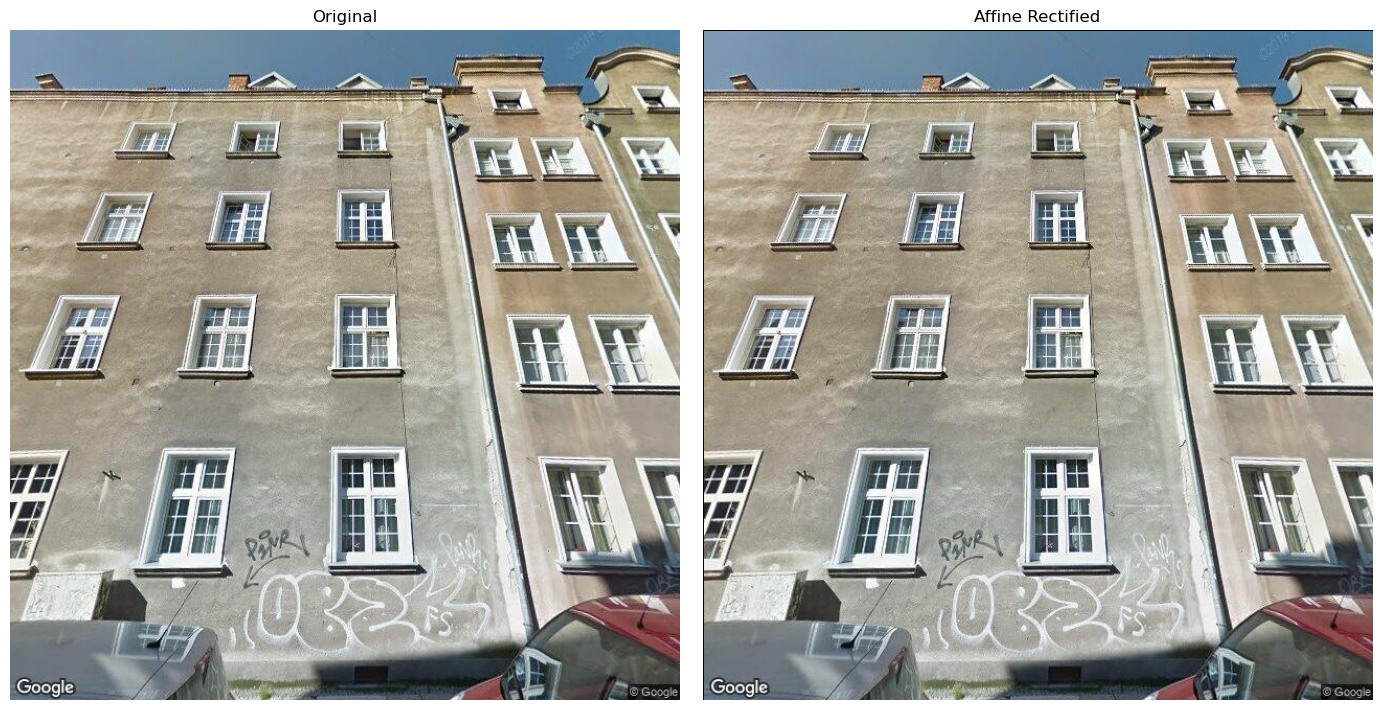


RESULTS
Vertical VP: (325.7, -414.8)
Horizontal VP: At infinity (parallel façade)



In [12]:
"""
Affine Rectification for Nearly-Parallel Façades
================================================
For street-view images where:
- Camera perpendicular to façade (90° to road)
- Camera tilted down/up to capture full building
- Façade is fronto-parallel → horizontal VP at infinity
- Only vertical VP and line at infinity are needed

Based on: Liu 2011 - "Automatic Facade Image Rectification..."
Method: 4-point correspondence from 2 VPs (one may be at infinity)

Requirements: numpy, opencv-python, matplotlib, scipy
"""

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import least_squares
from scipy.ndimage import median_filter

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def _to_h(x):
    """Convert 2D point to homogeneous coordinates."""
    x = np.asarray(x, dtype=np.float64).ravel()
    return np.array([x[0], x[1], 1.0], dtype=np.float64) if x.size == 2 else x

def _unit(v):
    """Normalize vector to unit length."""
    v = np.asarray(v, dtype=np.float64)
    n = np.linalg.norm(v)
    return v / max(n, 1e-12)

def angle_between_vectors(v1, v2):
    """Compute angle between two vectors in degrees."""
    v1 = np.asarray(v1, float)
    v2 = np.asarray(v2, float)
    c = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-12)
    return np.degrees(np.arccos(np.clip(c, -1, 1)))

# ============================================================================
# LINE DETECTION (LSD)
# ============================================================================

def detect_lines_lsd(img_gray, img_rgb=None, visualize=True):
    """Detect line segments using LSD."""
    print("[DEBUG] Running LSD line detector...")
    lsd = cv2.createLineSegmentDetector(0)
    lines, _, _, _ = lsd.detect(img_gray)
    
    if lines is None:
        print("  ⚠️ No lines detected.")
        return np.array([]).reshape(0, 4)
    
    lines = lines.reshape(-1, 4)
    print(f"  ✓ Detected {len(lines)} lines")
    
    if visualize and img_rgb is not None:
        plt.figure(figsize=(8, 8))
        plt.imshow(img_rgb)
        for l in lines:
            plt.plot([l[0], l[2]], [l[1], l[3]], color='cyan', linewidth=1)
        plt.title("All LSD Lines")
        plt.axis('off')
        plt.show()
    
    return lines

def line_angle_deg(line):
    """Compute angle of line in degrees [0, 180)."""
    x1, y1, x2, y2 = line
    ang = np.degrees(np.arctan2(y2 - y1, x2 - x1))
    return ang + 180 if ang < 0 else ang

def filter_by_angle(lines, amin, amax):
    """Filter lines by angle range."""
    ang = np.array([line_angle_deg(l) for l in lines])
    if amin <= amax:
        mask = (ang >= amin) & (ang <= amax)
    else:
        mask = (ang >= amin) | (ang <= amax)
    return lines[mask]

def filter_by_length(lines, min_len):
    """Filter lines by minimum length."""
    lens = np.sqrt((lines[:,2] - lines[:,0])**2 + (lines[:,3] - lines[:,1])**2)
    return lines[lens >= min_len]

def filter_by_mask(lines, mask, thr=0.5):
    """Filter lines by overlap with binary mask."""
    if mask is None:
        return lines
    
    filtered = []
    H, W = mask.shape[:2]
    for line in lines:
        x1, y1, x2, y2 = line
        xs = np.linspace(x1, x2, 20)
        ys = np.linspace(y1, y2, 20)
        xi = np.clip(xs.astype(int), 0, W - 1)
        yi = np.clip(ys.astype(int), 0, H - 1)
        if mask[yi, xi].mean() >= thr:
            filtered.append(line)
    return np.array(filtered) if filtered else np.empty((0, 4))

# ============================================================================
# VANISHING POINT ESTIMATION
# ============================================================================

def line_to_homogeneous(line):
    """Convert line segment to homogeneous line representation."""
    x1, y1, x2, y2 = line
    P1 = np.array([x1, y1, 1.0])
    P2 = np.array([x2, y2, 1.0])
    l = np.cross(P1, P2)
    return l / (np.linalg.norm(l[:2]) + 1e-9)

def line_midpoint(line):
    """Compute midpoint of line segment."""
    x1, y1, x2, y2 = line
    return np.array([(x1 + x2) / 2, (y1 + y2) / 2])

def compute_line_vp_angle(line, vp):
    """Compute angle between line direction and line-to-VP direction."""
    mid = line_midpoint(line)
    x1, y1, x2, y2 = line
    ld = np.array([x2 - x1, y2 - y1])
    ld = ld / (np.linalg.norm(ld) + 1e-12)
    vd = vp - mid
    vd = vd / (np.linalg.norm(vd) + 1e-12)
    ang = angle_between_vectors(ld, vd)
    return min(ang, 180 - ang)

def optimize_vp_lm(lines, vp_init):
    """Refine VP estimate using Levenberg-Marquardt."""
    def residuals(vp_flat):
        vp = vp_flat.reshape(2)
        return np.array([compute_line_vp_angle(line, vp) for line in lines])
    
    res = least_squares(residuals, vp_init.flatten(), method='lm')
    return res.x.reshape(2)
    

    
def ransac_vp_with_angle_validation(lines, angle_threshold=10.0, 
                                    iterations=1000, inlier_ratio=0.99):
    """RANSAC-based VP estimation with angle validation."""
    if len(lines) < 2:
        return None, np.array([], dtype=bool)
    
    print(f"  RANSAC: {len(lines)} lines, threshold={angle_threshold}°")
    
    n_lines = len(lines)
    best_inliers = np.array([], dtype=bool)
    best_vp = None
    best_angle_std = np.inf
    rng = np.random.default_rng(42)
    N = iterations
    
    for _ in range(N):
        sample_size = max(2, n_lines // 2)
        idx = rng.choice(n_lines, size=sample_size, replace=False)
        sample_lines = lines[idx]
        
        # Find VP candidates from line intersections
        intersections = []
        for i in range(len(sample_lines)):
            for j in range(i + 1, len(sample_lines)):
                l1 = line_to_homogeneous(sample_lines[i])
                l2 = line_to_homogeneous(sample_lines[j])
                vp_h = np.cross(l1, l2)
                if abs(vp_h[2]) > 1e-9:
                    intersections.append(vp_h[:2] / vp_h[2])
        
        if len(intersections) < 2:
            continue
        
        vp_init = np.mean(intersections, axis=0)
        
        try:
            vp_cand = optimize_vp_lm(sample_lines, vp_init)
        except Exception:
            continue
        
        # Compute inliers
        ang = np.array([compute_line_vp_angle(l, vp_cand) for l in lines])
        inl = ang < angle_threshold
        n_inl = int(np.sum(inl))
        
        if n_inl == 0:
            continue
        
        s = float(np.std(ang[inl]))
        
        if (n_inl > np.sum(best_inliers)) or \
           (n_inl == np.sum(best_inliers) and s < best_angle_std):
            best_inliers = inl
            best_vp = vp_cand
            best_angle_std = s
            
            # Adaptive iterations
            e = 1 - (n_inl / n_lines)
            if e < 1.0:
                eps = 1e-12
                num = np.clip(1 - (1 - e)**4, eps, 1 - eps)
                denom = np.clip(1 - num, eps, 1 - eps)
                N_new = int(np.log(1 - inlier_ratio + eps) / np.log(denom))
                if N_new > 0:
                    N = min(N, N_new)
    
    if best_vp is None:
        print("  ✗ RANSAC failed")
        return None, np.array([], dtype=bool)
    
    # Final refinement
    inlier_lines = lines[best_inliers]
    vp_final = optimize_vp_lm(inlier_lines, best_vp)
    
    # Recompute final inliers
    ang = np.array([compute_line_vp_angle(l, vp_final) for l in lines])
    final_inl = ang < angle_threshold
    
    print(f"  ✓ VP: ({vp_final[0]:.1f}, {vp_final[1]:.1f})")
    print(f"  ✓ Inliers: {np.sum(final_inl)}/{len(lines)}")
    
    return vp_final, final_inl
    
def visualize_vp_with_extended_lines(img, lines, vp, title="VP Detection"):
    vis = img.copy()
    h, w = img.shape[:2]
    for line in lines:
        x1,y1,x2,y2 = line
        mid = line_midpoint(line)
        d = vp - mid; n = np.linalg.norm(d)
        if n < 1e-9: continue
        d = d / n
        t = 2000
        p_end = mid + t*d; p_start = mid - t*d
        cv2.line(vis, tuple(p_start.astype(int)), tuple(p_end.astype(int)),
                 (0,255,0), 2, cv2.LINE_AA)
        cv2.line(vis, (int(x1),int(y1)), (int(x2),int(y2)), (0,255,255), 3, cv2.LINE_AA)
    vp_int = tuple(vp.astype(int)); center = np.array([w/2, h/2])
    if 0 <= vp[0] < w and 0 <= vp[1] < h:
        cv2.circle(vis, vp_int, 10, (255,0,255), -1, cv2.LINE_AA)
    else:
        d = vp - center; d = d / (np.linalg.norm(d)+1e-12)
        arrow_len = min(w,h)//4; arrow_end = (center + arrow_len*d).astype(int)
        cv2.arrowedLine(vis, tuple(center.astype(int)), tuple(arrow_end),
                        (255,0,255), 4, cv2.LINE_AA, tipLength=0.3)
    return vis

# ============================================================================
# AFFINE RECTIFICATION (Paper Method - Section 3)
# ============================================================================
def intersect_from_vps(vp_v, vp_h, img_shape):
    """Compute 4-point rectification quad (A,B,C,D) from VP_v and VP_h."""
    h, w = img_shape[:2] #extracts the height and width of the input image.

    def line(p1, p2):
        return np.cross(_to_h(p1), _to_h(p2))

    # Lines from vertical VP through midpoints of left/right edges
    lv_left = line(vp_v, (0, h // 2)) # VP_v → left edge midpoint
    lv_right = line(vp_v, (w, h // 2)) # VP_v → right edge midpoint

    # Lines from horizontal VP through midpoints of top/bottom edges
    lh_top = line(vp_h, (w // 2, 0)) # VP_h → top edge midpoint
    lh_bottom = line(vp_h, (w // 2, h)) # VP_h → bottom edge midpoint
 
    def intersect(l1, l2):
        pt = np.cross(l1, l2)
        return pt[:2] / pt[2]

    # Intersections define quad corners
    A = intersect(lv_left, lh_top)      # Top-left
    B = intersect(lv_right, lh_top)     # Top-right
    C = intersect(lv_right, lh_bottom)  # Bottom-right
    D = intersect(lv_left, lh_bottom)   # Bottom-left

    return np.array([A, B, C, D], dtype=np.float64)
def compute_4point_homography_from_vps(vp_vertical, vp_horizontal_or_none, 
                                       img_shape, margin_factor=0.1):
    """
    Compute homography using 4-point correspondence method from paper.
    
    From Liu 2011, Section 3.1:
    "Project lines from vanishing points to image, intersect at A,B,C,D.
     Map these to image corners → rectified image."
    
    Args:
        vp_vertical: Vertical vanishing point (x, y)
        vp_horizontal_or_none: Horizontal VP or None (if at infinity)
        img_shape: (height, width) of image
        margin_factor: Factor to extend lines beyond image bounds
    
    Returns:
        H: 3x3 homography matrix
        rect_width, rect_height: Output dimensions
    """
    h, w = img_shape[:2]
    
    print("\n" + "="*60)
    print("COMPUTING 4-POINT HOMOGRAPHY")
    print("="*60)
    
    # Image corners
    img_corners = np.array([
        [0, 0],      # top-left
        [w, 0],      # top-right
        [w, h],      # bottom-right
        [0, h]       # bottom-left
    ], dtype=np.float64)
    
    # Check if horizontal VP is at infinity
    h_at_infinity = (vp_horizontal_or_none is None or
                     np.linalg.norm(vp_horizontal_or_none) > w * 10)
    
    if h_at_infinity:
        print("  Horizontal VP at infinity → façade parallel to camera")
        print("  Using affine rectification (vertical correction only)")
        
        # For parallel façade: only fix vertical perspective
        # Horizontal lines stay horizontal (parallel)
        
        # Project vertical lines from vp_vertical
        vp_v = vp_vertical
        
        # Find where vertical VP projections intersect image edges
        # Left edge: line from vp_v through (0, h/2)
        # Right edge: line from vp_v through (w, h/2)
        
        def intersect_line_with_image_boundary(p1, p2, w, h):
            """Find where line p1->p2 intersects image boundary."""
            # Parametric line: P = p1 + t*(p2-p1)
            # Find t for each boundary
            d = p2 - p1
            if abs(d[0]) < 1e-9 and abs(d[1]) < 1e-9:
                return p1
            
            candidates = []
            # Left edge (x=0)
            if abs(d[0]) > 1e-9:
                t = -p1[0] / d[0]
                y = p1[1] + t * d[1]
                if 0 <= y <= h and t > 0:
                    candidates.append([0, y])
            # Right edge (x=w)
            if abs(d[0]) > 1e-9:
                t = (w - p1[0]) / d[0]
                y = p1[1] + t * d[1]
                if 0 <= y <= h and t > 0:
                    candidates.append([w, y])
            # Top edge (y=0)
            if abs(d[1]) > 1e-9:
                t = -p1[1] / d[1]
                x = p1[0] + t * d[0]
                if 0 <= x <= w and t > 0:
                    candidates.append([x, 0])
            # Bottom edge (y=h)
            if abs(d[1]) > 1e-9:
                t = (h - p1[1]) / d[1]
                x = p1[0] + t * d[0]
                if 0 <= x <= w and t > 0:
                    candidates.append([x, h])
            
            if len(candidates) == 0:
                return p1
            # Return farthest intersection
            return np.array(max(candidates, key=lambda p: np.linalg.norm(np.array(p)-p1)))
        
        # Four correspondence points (A, B, C, D from paper)
        # Top-left corner projects to A
        A = intersect_line_with_image_boundary(vp_v, np.array([0, 0]), w, h)
        # Top-right corner projects to B  
        B = intersect_line_with_image_boundary(vp_v, np.array([w, 0]), w, h)
        # Bottom-right corner projects to C
        C = intersect_line_with_image_boundary(vp_v, np.array([w, h]), w, h)
        # Bottom-left corner projects to D
        D = intersect_line_with_image_boundary(vp_v, np.array([0, h]), w, h)
        
        src_points = np.array([A, B, C, D], dtype=np.float64)
        
        # Target: rectangle with same aspect ratio
        # Width: average of top and bottom
        top_width = np.linalg.norm(B - A)
        bottom_width = np.linalg.norm(C - D)
        avg_width = (top_width + bottom_width) / 2
        
        # Height: average of left and right
        left_height = np.linalg.norm(D - A)
        right_height = np.linalg.norm(C - B)
        avg_height = (left_height + right_height) / 2
        
        rect_width = int(avg_width)
        rect_height = int(avg_height)
        
    else:
        print(f"  Horizontal VP: ({vp_horizontal_or_none[0]:.1f}, {vp_horizontal_or_none[1]:.1f})")
        print("  Using full perspective rectification")
    
        src_points = intersect_from_vps(vp_vertical, vp_horizontal_or_none, img_shape)
    
        # Compute approximate output size
        top_width = np.linalg.norm(src_points[1] - src_points[0])
        bottom_width = np.linalg.norm(src_points[2] - src_points[3])
        left_height = np.linalg.norm(src_points[3] - src_points[0])
        right_height = np.linalg.norm(src_points[2] - src_points[1])

        rect_width = int(round((top_width + bottom_width) / 2))
        rect_height = int(round((left_height + right_height) / 2))
    
    # Target points: corners of rectified rectangle
    dst_points = np.array([
        [0, 0],
        [rect_width, 0],
        [rect_width, rect_height],
        [0, rect_height]
    ], dtype=np.float64)
    
    print(f"\n  Source points (ABCD):")
    for i, pt in enumerate(src_points):
        print(f"    {['A','B','C','D'][i]}: ({pt[0]:.1f}, {pt[1]:.1f})")
    
    print(f"\n  Output dimensions: {rect_width}×{rect_height}")
    
    # Compute homography
    H, _ = cv2.findHomography(src_points, dst_points, method=0)
    
    return H, rect_width, rect_height


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def rectify_parallel_facade(img_path,
                           seg_path=None,
                           building_label=1,
                           cam_height_m=2.5,
                           camera_tilt_deg=25.0,
                           output_dir=None,
                           visualize=True):
    """
    Affine rectification for nearly-parallel façades.
    
    Args:
        img_path: Path to input image
        seg_path: Path to segmentation mask
        building_label: Label for building in mask
        cam_height_m: Camera height above ground
        camera_tilt_deg: Camera tilt (positive = downward)
        output_dir: Output directory
        visualize: Show visualizations
    
    Returns:
        dict with results
    """
    print("\n" + "="*80)
    print(f"AFFINE RECTIFICATION: {os.path.basename(img_path)}")
    print("="*80)
    print(f"Scenario: Façade parallel to camera, tilt={camera_tilt_deg}°")
    
    # Load image
    img_bgr = cv2.imread(img_path)
    assert img_bgr is not None
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    print(f"\nImage: {w}×{h} pixels")
    
    # Load mask
    mask = None
    if seg_path and os.path.exists(seg_path):
        seg = np.load(seg_path)["seg"]
        mask = (seg == building_label).astype(np.uint8) * 255
        print(f"Mask: loaded")
    
    # Detect lines
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    all_lines = detect_lines_lsd(gray, img_rgb=img, visualize=True)
    
    # ========== VERTICAL VP ==========
    print("\n" + "="*60)
    print("VERTICAL VP DETECTION")
    print("="*60)
    
    vert_lines = filter_by_angle(all_lines, 60, 120)
    vert_lines = filter_by_length(vert_lines, 30)
    if mask is not None:
        vert_lines = filter_by_mask(vert_lines, mask, 0.5)
    
    print(f"Vertical lines: {len(vert_lines)}")
    
    if len(vert_lines) < 5:
        raise RuntimeError("Too few vertical lines")
    
    vp_v, v_inliers = ransac_vp_with_angle_validation(vert_lines, angle_threshold=10.0)
    
    if vp_v is None:
        raise RuntimeError("Vertical VP estimation failed")

    vis_v = visualize_vp_with_extended_lines(
    img,
    vert_lines[v_inliers],
    vp_v,
    title="Vertical VP (inliers extended)")

    
    # ========== HORIZONTAL VP ==========
    print("\n" + "="*60)
    print("HORIZONTAL VP DETECTION")
    print("="*60)
    
    horiz_lines = np.concatenate([
        filter_by_angle(all_lines, 0, 30),
        filter_by_angle(all_lines, 150, 180)
    ], axis=0)
    horiz_lines = filter_by_length(horiz_lines, 30)
    if mask is not None:
        horiz_lines = filter_by_mask(horiz_lines, mask, 0.5)
    
    print(f"Horizontal lines: {len(horiz_lines)}")


    vp_h = None
    if len(horiz_lines) >= 5:
        vp_h, h_inliers = ransac_vp_with_angle_validation(horiz_lines, angle_threshold=10.0)
        
        if vp_h is not None:
            # Check if VP is very far (at infinity)
            dist = np.linalg.norm(vp_h - np.array([w/2, h/2]))
            if dist > w * 5:
                print(f"  ✓ Horizontal VP very far ({dist/w:.1f}×width) → At infinity")
                vp_h = None
            else:
                print(f"  ✓ Horizontal VP at finite distance")
    else:
        print("  ⚠️ Few horizontal lines → VP likely at infinity")

    if vp_h is not None:
        vis_h = visualize_vp_with_extended_lines(
            img,
            horiz_lines[h_inliers],
            vp_h,
            title="Horizontal VP (inliers extended)"
        )
    else:
        vis_h = None

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(vis_v)
    plt.title("Vertical VP (inliers extended)")
    plt.axis("off")

    if vis_h is not None:
        plt.subplot(1, 2, 2)
        plt.imshow(vis_h)
        plt.title("Horizontal VP (inliers extended)")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    
    
    # ========== AFFINE RECTIFICATION ==========
    H, rect_w, rect_h = compute_4point_homography_from_vps(
        vp_v, vp_h, (h, w)
    )
    
    # === Padded Warp to Preserve Full Rectified Façade ===
    # Compute where the image corners will go after homography
    img_corners = np.array([
        [0, 0],
        [w, 0],
        [w, h],
        [0, h]
    ], dtype=np.float32)

    proj_corners = cv2.perspectiveTransform(img_corners[None], H)[0]

    # Get bounding box of transformed image
    x_min = int(np.floor(np.min(proj_corners[:, 0])))
    x_max = int(np.ceil(np.max(proj_corners[:, 0])))
    y_min = int(np.floor(np.min(proj_corners[:, 1])))
    y_max = int(np.ceil(np.max(proj_corners[:, 1])))

    pad_width = x_max - x_min
    pad_height = y_max - y_min

    # Translate rectified image so all content fits into positive quadrant
    T = np.array([
        [1, 0, -x_min],
        [0, 1, -y_min],
        [0, 0, 1]
    ], dtype=np.float64)

    H_padded = T @ H

    # # # Warp with black padding and expanded canvas

    # Warp with black padding and expanded canvas
    img_rect = cv2.warpPerspective(
        img, H_padded,
        (pad_width, pad_height),
        flags=cv2.INTER_LINEAR,
        borderValue=(0, 0, 0)  # black padding
        )
    
    
    # ========== SAVE & VISUALIZE ==========
    if output_dir:
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        base = Path(img_path).stem
        cv2.imwrite(
            os.path.join(output_dir, f"{base}_rectified_affine.png"),
            cv2.cvtColor(img_rect, cv2.COLOR_RGB2BGR)
        )
        np.savez(
            os.path.join(output_dir, f"{base}_affine_meta.npz"),
            H=H,
            vp_v=vp_v,
            vp_h=vp_h if vp_h is not None else np.array([np.inf, np.inf])
            # meters_per_pixel=meters_per_pixel
        )
        print(f"\n✓ Saved outputs to: {output_dir}")
    
    if visualize:
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))
        axes[0].imshow(img)
        axes[0].set_title("Original")
        axes[0].axis('off')
        
        axes[1].imshow(img_rect)
        axes[1].set_title("Affine Rectified")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    print("\n" + "="*80)
    print("RESULTS")
    print("="*80)
    print(f"Vertical VP: ({vp_v[0]:.1f}, {vp_v[1]:.1f})")
    if vp_h is not None:
        print(f"Horizontal VP: ({vp_h[0]:.1f}, {vp_h[1]:.1f})")
    else:
        print("Horizontal VP: At infinity (parallel façade)")
    # print(f"Scale: {meters_per_pixel*100:.2f} cm/pixel")
    print("="*80 + "\n")
    
    return {
        'img_rect': img_rect,
        'H': H,
        'vp_v': vp_v,
        'vp_h': vp_h
        # 'meters_per_pixel': meters_per_pixel
    }

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__":
    IMG_PATH = "/users/project1/pt01183/Building-height-width/Gdańsk, Poland/save_rgb/imgs/16_279.jpg"
    SEG_PATH = "/users/project1/pt01183/Building-height-width/Gdańsk, Poland/seg/16_279_seg.npz"
    OUT_DIR = "./rectified_affine"

    result = rectify_parallel_facade(
        img_path=IMG_PATH,
        seg_path=SEG_PATH,
        building_label=1,
        cam_height_m=2.5,
        camera_tilt_deg=25.0,
        output_dir=OUT_DIR,
        visualize=True
    )

## for Vertical VP only


FAÇADE RECTIFICATION: street_view_image.jpg
Image: 640×640 pixels
Segmentation mask (PNG): loaded
[DEBUG] Running LSD line detector...
  ✓ Detected 924 lines


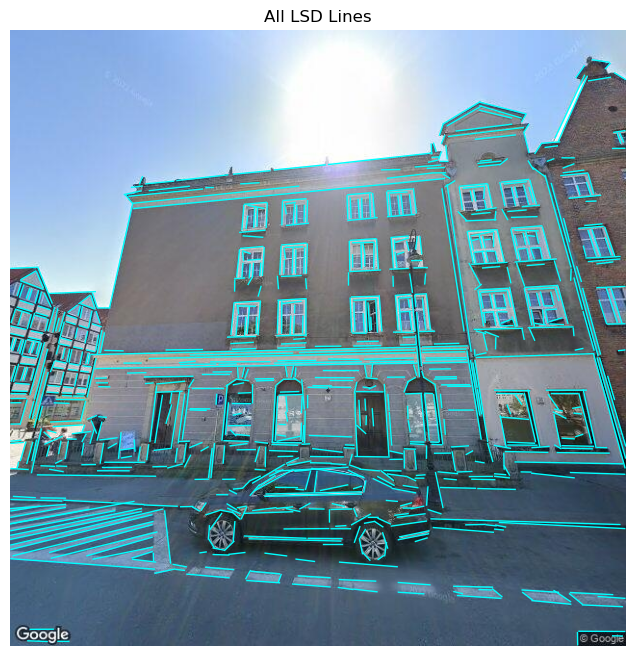


VERTICAL VP DETECTION
Vertical lines: 80
  RANSAC: 80 lines, threshold=10.0°


In [ ]:
"""
Affine Rectification for Nearly-Parallel Façades with Mask Support
==================================================================
For street-view images where:
- Camera perpendicular to façade (90° to road)
- Camera tilted down/up to capture full building
- Façade is fronto-parallel → horizontal VP at infinity
- Only vertical VP and line at infinity are needed

Requirements: numpy, opencv-python, matplotlib, scipy
"""

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import least_squares

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def _to_h(x):
    """Convert 2D point to homogeneous coordinates."""
    x = np.asarray(x, dtype=np.float64).ravel()
    return np.array([x[0], x[1], 1.0], dtype=np.float64) if x.size == 2 else x

def _unit(v):
    """Normalize vector to unit length."""
    v = np.asarray(v, dtype=np.float64)
    n = np.linalg.norm(v)
    return v / max(n, 1e-12)

def angle_between_vectors(v1, v2):
    """Compute angle between two vectors in degrees."""
    v1 = np.asarray(v1, float)
    v2 = np.asarray(v2, float)
    c = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-12)
    return np.degrees(np.arccos(np.clip(c, -1, 1)))

def K_from_hfov(width, height, hfov_deg):
    """Build camera intrinsic matrix from horizontal FOV."""
    hfov = np.deg2rad(hfov_deg)
    f = 0.5 * width / np.tan(0.5 * hfov)
    cx, cy = width/2, height/2
    return np.array([[f,0,cx],[0,f,cy],[0,0,1]], float)

# ============================================================================
# LINE DETECTION (LSD)
# ============================================================================

def detect_lines_lsd(img_gray, img_rgb=None, visualize=True):
    """Detect line segments using LSD."""
    print("[DEBUG] Running LSD line detector...")
    lsd = cv2.createLineSegmentDetector(0)
    lines, _, _, _ = lsd.detect(img_gray)
    
    if lines is None:
        print("  ⚠️ No lines detected.")
        return np.array([]).reshape(0, 4)
    
    lines = lines.reshape(-1, 4)
    print(f"  ✓ Detected {len(lines)} lines")
    
    if visualize and img_rgb is not None:
        plt.figure(figsize=(8, 8))
        plt.imshow(img_rgb)
        for l in lines:
            plt.plot([l[0], l[2]], [l[1], l[3]], color='cyan', linewidth=1)
        plt.title("All LSD Lines")
        plt.axis('off')
        plt.show()
    
    return lines

def line_angle_deg(line):
    """Compute angle of line in degrees [0, 180)."""
    x1, y1, x2, y2 = line
    ang = np.degrees(np.arctan2(y2 - y1, x2 - x1))
    return ang + 180 if ang < 0 else ang

def filter_by_angle(lines, amin, amax):
    """Filter lines by angle range."""
    ang = np.array([line_angle_deg(l) for l in lines])
    if amin <= amax:
        mask = (ang >= amin) & (ang <= amax)
    else:
        mask = (ang >= amin) | (ang <= amax)
    return lines[mask]

def filter_by_length(lines, min_len):
    """Filter lines by minimum length."""
    lens = np.sqrt((lines[:,2] - lines[:,0])**2 + (lines[:,3] - lines[:,1])**2)
    return lines[lens >= min_len]

def filter_by_mask(lines, mask, thr=0.5):
    """Filter lines by overlap with binary mask."""
    if mask is None:
        return lines
    
    filtered = []
    H, W = mask.shape[:2]
    for line in lines:
        x1, y1, x2, y2 = line
        xs = np.linspace(x1, x2, 20)
        ys = np.linspace(y1, y2, 20)
        xi = np.clip(xs.astype(int), 0, W - 1)
        yi = np.clip(ys.astype(int), 0, H - 1)
        if mask[yi, xi].mean() >= thr:
            filtered.append(line)
    return np.array(filtered) if filtered else np.empty((0, 4))

# ============================================================================
# VANISHING POINT ESTIMATION
# ============================================================================

def line_to_homogeneous(line):
    """Convert line segment to homogeneous line representation."""
    x1, y1, x2, y2 = line
    P1 = np.array([x1, y1, 1.0])
    P2 = np.array([x2, y2, 1.0])
    l = np.cross(P1, P2)
    return l / (np.linalg.norm(l[:2]) + 1e-9)

def line_midpoint(line):
    """Compute midpoint of line segment."""
    x1, y1, x2, y2 = line
    return np.array([(x1 + x2) / 2, (y1 + y2) / 2])

def compute_line_vp_angle(line, vp):
    """Compute angle between line direction and line-to-VP direction."""
    mid = line_midpoint(line)
    x1, y1, x2, y2 = line
    ld = np.array([x2 - x1, y2 - y1])
    ld = ld / (np.linalg.norm(ld) + 1e-12)
    vd = vp - mid
    vd = vd / (np.linalg.norm(vd) + 1e-12)
    ang = angle_between_vectors(ld, vd)
    return min(ang, 180 - ang)

def optimize_vp_lm(lines, vp_init):
    """Refine VP estimate using Levenberg-Marquardt."""
    def residuals(vp_flat):
        vp = vp_flat.reshape(2)
        return np.array([compute_line_vp_angle(line, vp) for line in lines])
    
    res = least_squares(residuals, vp_init.flatten(), method='lm')
    return res.x.reshape(2)

def ransac_vp_with_angle_validation(lines, angle_threshold=10.0, 
                                    iterations=1000, inlier_ratio=0.99):
    """RANSAC-based VP estimation with angle validation."""
    if len(lines) < 2:
        return None, np.array([], dtype=bool)
    
    print(f"  RANSAC: {len(lines)} lines, threshold={angle_threshold}°")
    
    n_lines = len(lines)
    best_inliers = np.array([], dtype=bool)
    best_vp = None
    best_angle_std = np.inf
    rng = np.random.default_rng(42)
    N = iterations
    
    for _ in range(N):
        sample_size = max(2, n_lines // 2)
        idx = rng.choice(n_lines, size=sample_size, replace=False)
        sample_lines = lines[idx]
        
        # Find VP candidates from line intersections
        intersections = []
        for i in range(len(sample_lines)):
            for j in range(i + 1, len(sample_lines)):
                l1 = line_to_homogeneous(sample_lines[i])
                l2 = line_to_homogeneous(sample_lines[j])
                vp_h = np.cross(l1, l2)
                if abs(vp_h[2]) > 1e-9:
                    intersections.append(vp_h[:2] / vp_h[2])
        
        if len(intersections) < 2:
            continue
        
        vp_init = np.mean(intersections, axis=0)
        
        try:
            vp_cand = optimize_vp_lm(sample_lines, vp_init)
        except Exception:
            continue
        
        # Compute inliers
        ang = np.array([compute_line_vp_angle(l, vp_cand) for l in lines])
        inl = ang < angle_threshold
        n_inl = int(np.sum(inl))
        
        if n_inl == 0:
            continue
        
        s = float(np.std(ang[inl]))
        
        if (n_inl > np.sum(best_inliers)) or \
           (n_inl == np.sum(best_inliers) and s < best_angle_std):
            best_inliers = inl
            best_vp = vp_cand
            best_angle_std = s
            
            # Adaptive iterations
            e = 1 - (n_inl / n_lines)
            if e < 1.0:
                eps = 1e-12
                num = np.clip(1 - (1 - e)**4, eps, 1 - eps)
                denom = np.clip(1 - num, eps, 1 - eps)
                N_new = int(np.log(1 - inlier_ratio + eps) / np.log(denom))
                if N_new > 0:
                    N = min(N, N_new)
    
    if best_vp is None:
        print("  ✗ RANSAC failed")
        return None, np.array([], dtype=bool)
    
    # Final refinement
    inlier_lines = lines[best_inliers]
    vp_final = optimize_vp_lm(inlier_lines, best_vp)
    
    # Recompute final inliers
    ang = np.array([compute_line_vp_angle(l, vp_final) for l in lines])
    final_inl = ang < angle_threshold
    
    print(f"  ✓ VP: ({vp_final[0]:.1f}, {vp_final[1]:.1f})")
    print(f"  ✓ Inliers: {np.sum(final_inl)}/{len(lines)}")
    
    return vp_final, final_inl

def visualize_vp_with_extended_lines(img, lines, vp, title="VP Detection"):
    """Visualize vanishing point with extended lines."""
    vis = img.copy()
    h, w = img.shape[:2]
    for line in lines:
        x1,y1,x2,y2 = line
        mid = line_midpoint(line)
        d = vp - mid
        n = np.linalg.norm(d)
        if n < 1e-9:
            continue
        d = d / n
        t = 2000
        p_end = mid + t*d
        p_start = mid - t*d
        cv2.line(vis, tuple(p_start.astype(int)), tuple(p_end.astype(int)),
                 (0,255,0), 2, cv2.LINE_AA)
        cv2.line(vis, (int(x1),int(y1)), (int(x2),int(y2)), (0,255,255), 3, cv2.LINE_AA)
    
    vp_int = tuple(vp.astype(int))
    center = np.array([w/2, h/2])
    if 0 <= vp[0] < w and 0 <= vp[1] < h:
        cv2.circle(vis, vp_int, 10, (255,0,255), -1, cv2.LINE_AA)
    else:
        d = vp - center
        d = d / (np.linalg.norm(d)+1e-12)
        arrow_len = min(w,h)//4
        arrow_end = (center + arrow_len*d).astype(int)
        cv2.arrowedLine(vis, tuple(center.astype(int)), tuple(arrow_end),
                        (255,0,255), 4, cv2.LINE_AA, tipLength=0.3)
    return vis

# ============================================================================
# RECTIFICATION WITH PADDING
# ============================================================================

def compute_padded_homography(H, img_shape, margin=0.0):
    """
    Compute padded homography that ensures all warped content fits in canvas.
    
    Args:
        H: Original homography matrix
        img_shape: (height, width) of input image
        margin: Relative margin (0.1 = 10% extra space)
    
    Returns:
        H_padded: Adjusted homography with translation
        out_size: (width, height) of output canvas
    """
    h, w = img_shape[:2]
    
    # Transform image corners
    corners = np.array([
        [0, 0, 1],
        [w, 0, 1],
        [w, h, 1],
        [0, h, 1]
    ], dtype=float).T
    
    warped_corners = H @ corners
    warped_corners /= warped_corners[2, :]
    
    xs = warped_corners[0, :]
    ys = warped_corners[1, :]
    
    # Compute bounding box
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    
    box_w = x_max - x_min
    box_h = y_max - y_min
    
    # Add margin
    out_w = int(box_w * (1 + 2 * margin))
    out_h = int(box_h * (1 + 2 * margin))
    
    # Center the content
    offset_x = (out_w - box_w) / 2 - x_min
    offset_y = (out_h - box_h) / 2 - y_min
    
    # Translation matrix
    T = np.array([
        [1, 0, offset_x],
        [0, 1, offset_y],
        [0, 0, 1]
    ])
    
    H_padded = T @ H
    
    return H_padded, (out_w, out_h)

def warp_with_homography(img, H, out_size, is_mask=False):
    """
    Warp image or mask with given homography.
    
    Args:
        img: Input image (color or grayscale)
        H: Homography matrix (3x3)
        out_size: (width, height) of output
        is_mask: If True, use INTER_NEAREST for masks
    
    Returns:
        Warped image
    """
    interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR
    border_val = 0 if is_mask else (0, 0, 0)
    
    warped = cv2.warpPerspective(
        img, H, out_size,
        flags=interp,
        borderValue=border_val
    )
    
    return warped

# ============================================================================
# PITCH-ONLY RECTIFICATION
# ============================================================================

def compute_pitch_rotation_matrix(vp_v, img_shape, hfov_deg=90.0):
    """
    Compute rotation matrix to correct pitch from vertical VP.
    
    Args:
        vp_v: Vertical vanishing point (x, y)
        img_shape: (height, width) of image
        hfov_deg: Horizontal field of view in degrees
    
    Returns:
        R: 3x3 rotation matrix
        angle_deg: Pitch correction angle in degrees
    """
    h, w = img_shape[:2]
    K = K_from_hfov(w, h, hfov_deg)
    
    # Convert vertical VP to camera coordinates
    vp_v_h = _to_h(vp_v)
    v_cam = np.linalg.inv(K) @ vp_v_h
    v_cam = _unit(v_cam)
    
    # Ensure v_cam points down (negative y in camera frame)
    if v_cam[1] > 0:
        v_cam = -v_cam
    
    # Build rotation to align v_cam with world vertical
    y_world = np.array([0, -1, 0])  # World vertical (down)
    
    # Compute rotation axis (perpendicular to both vectors)
    axis = np.cross(v_cam, y_world)
    axis_norm = np.linalg.norm(axis)
    
    if axis_norm < 1e-6:
        # Already aligned
        return np.eye(3), 0.0
    
    axis = axis / axis_norm
    
    # Compute rotation angle
    cos_angle = np.dot(v_cam, y_world)
    angle = np.arccos(np.clip(cos_angle, -1, 1))
    
    # Rodrigues' rotation formula
    K_axis = np.array([
        [0, -axis[2], axis[1]],
        [axis[2], 0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])
    
    R = np.eye(3) + np.sin(angle) * K_axis + (1 - np.cos(angle)) * (K_axis @ K_axis)
    
    return R, np.degrees(angle)

# ============================================================================
# 4-POINT HOMOGRAPHY (for non-parallel cases)
# ============================================================================

def intersect_from_vps(vp_v, vp_h, img_shape):
    """Compute 4-point rectification quad from two VPs."""
    h, w = img_shape[:2]

    def line(p1, p2):
        return np.cross(_to_h(p1), _to_h(p2))

    # Lines from vertical VP through midpoints of left/right edges
    lv_left = line(vp_v, (0, h // 2))
    lv_right = line(vp_v, (w, h // 2))

    # Lines from horizontal VP through midpoints of top/bottom edges
    lh_top = line(vp_h, (w // 2, 0))
    lh_bottom = line(vp_h, (w // 2, h))
 
    def intersect(l1, l2):
        pt = np.cross(l1, l2)
        return pt[:2] / pt[2]

    # Intersections define quad corners
    A = intersect(lv_left, lh_top)
    B = intersect(lv_right, lh_top)
    C = intersect(lv_right, lh_bottom)
    D = intersect(lv_left, lh_bottom)

    return np.array([A, B, C, D], dtype=np.float64)

def compute_4point_homography(vp_v, vp_h, img_shape):
    """Compute homography from two finite vanishing points."""
    h, w = img_shape[:2]
    
    src_points = intersect_from_vps(vp_v, vp_h, img_shape)

    top_width = np.linalg.norm(src_points[1] - src_points[0])
    bottom_width = np.linalg.norm(src_points[2] - src_points[3])
    rect_width = int((top_width + bottom_width) / 2)

    left_height = np.linalg.norm(src_points[3] - src_points[0])
    right_height = np.linalg.norm(src_points[2] - src_points[1])
    rect_height = int((left_height + right_height) / 2)

    dst_points = np.array([
        [0, 0],
        [rect_width, 0],
        [rect_width, rect_height],
        [0, rect_height]
    ], dtype=float)

    H, _ = cv2.findHomography(src_points, dst_points)
    return H

# ============================================================================
# MAIN PIPELINE
# ============================================================================

def rectify_parallel_facade(img_path,
                           seg_path=None,
                           seg_vis_path=None,
                           building_label=1,
                           output_dir=None,
                           visualize=True):
    """
    Rectification for façades with automatic VP detection.
    Handles both fronto-parallel (pitch-only) and non-parallel cases.
    
    Args:
        img_path: Path to input image
        seg_path: Path to segmentation .npz file (for line filtering)
        seg_vis_path: Path to segmentation visualization PNG (to rectify)
        building_label: Label for building in .npz mask
        output_dir: Output directory (optional)
        visualize: Show visualizations
    
    Returns:
        dict with results including rectified image and mask
    """
    print("\n" + "="*80)
    print(f"FAÇADE RECTIFICATION: {os.path.basename(img_path)}")
    print("="*80)
    
    # ========== LOAD IMAGE ==========
    img_bgr = cv2.imread(img_path)
    assert img_bgr is not None, f"Cannot load image: {img_path}"
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    print(f"Image: {w}×{h} pixels")
    
    # ========== LOAD MASKS ==========
    # Load .npz mask for line filtering AND for rectification
    seg = None
    if seg_path and os.path.exists(seg_path):
        seg = np.load(seg_path)["seg"].astype(np.uint8)   # 0/1/2 labels
        mask = (seg == building_label).astype(np.uint8) * 255
        print(f"Segmentation (.npz): loaded")
    else:
        mask = None

    # Load visualization mask for rectification (optional, only for PNG output)
    seg_vis = None
    if seg_vis_path and os.path.exists(seg_vis_path):
        seg_vis = cv2.imread(seg_vis_path, cv2.COLOR_RGB2BGR)
        if seg_vis is not None:
            print(f"Segmentation mask (PNG): loaded")
    
    # ========== DETECT LINES ==========
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    all_lines = detect_lines_lsd(gray, img_rgb=img, visualize=visualize)
    
    # ========== VERTICAL VP ==========
    print("\n" + "="*60)
    print("VERTICAL VP DETECTION")
    print("="*60)
    
    vert_lines = filter_by_angle(all_lines, 60, 120)
    vert_lines = filter_by_length(vert_lines, 30)
    if mask is not None:
        vert_lines = filter_by_mask(vert_lines, mask, 0.5)
    
    print(f"Vertical lines: {len(vert_lines)}")
    
    if len(vert_lines) < 5:
        raise RuntimeError("Too few vertical lines")
    
    vp_v, v_inliers = ransac_vp_with_angle_validation(vert_lines, angle_threshold=10.0)
    
    if vp_v is None:
        raise RuntimeError("Vertical VP estimation failed")

    if visualize:
        vis_v = visualize_vp_with_extended_lines(
            img, vert_lines[v_inliers], vp_v,
            title="Vertical VP (inliers extended)"
        )
    
    # ========== HORIZONTAL VP ==========
    print("\n" + "="*60)
    print("HORIZONTAL VP DETECTION")
    print("="*60)
    
    horiz_lines = np.concatenate([
        filter_by_angle(all_lines, 0, 30),
        filter_by_angle(all_lines, 150, 180)
    ], axis=0)
    horiz_lines = filter_by_length(horiz_lines, 30)
    if mask is not None:
        horiz_lines = filter_by_mask(horiz_lines, mask, 0.5)
    
    print(f"Horizontal lines: {len(horiz_lines)}")

    vp_h = None
    if len(horiz_lines) >= 5:
        vp_h, h_inliers = ransac_vp_with_angle_validation(horiz_lines, angle_threshold=10.0)
        
        if vp_h is not None:
            # Check if VP is very far (at infinity)
            dist = np.linalg.norm(vp_h - np.array([w/2, h/2]))
            if dist > w * 5:
                print(f"  ✓ Horizontal VP very far ({dist/w:.1f}×width) → At infinity")
                vp_h = None
            else:
                print(f"  ✓ Horizontal VP at finite distance")
                if visualize:
                    vis_h = visualize_vp_with_extended_lines(
                        img, horiz_lines[h_inliers], vp_h,
                        title="Horizontal VP (inliers extended)"
                    )
    else:
        print("  ⚠️ Few horizontal lines → VP likely at infinity")

    # Visualization
    if visualize:
        if vp_h is not None:
            plt.figure(figsize=(12, 6))
            plt.subplot(1, 2, 1)
            plt.imshow(vis_v)
            plt.title("Vertical VP")
            plt.axis("off")
            plt.subplot(1, 2, 2)
            plt.imshow(vis_h)
            plt.title("Horizontal VP")
            plt.axis("off")
        else:
            plt.figure(figsize=(8, 8))
            plt.imshow(vis_v)
            plt.title("Vertical VP (Horizontal at ∞)")
            plt.axis("off")
        plt.tight_layout()
        plt.show()
    
    # ========== COMPUTE RECTIFICATION ==========
    if vp_h is None:
        # CASE 1: Pitch-only rectification
        print("\n" + "="*60)
        print("PITCH-ONLY RECTIFICATION (Horizontal VP = ∞)")
        print("="*60)
        
        R, angle_deg = compute_pitch_rotation_matrix(vp_v, (h, w), hfov_deg=90.0)
        K = K_from_hfov(w, h, hfov_deg=90.0)
        H = K @ R @ np.linalg.inv(K)
        
        print(f"  Pitch correction angle: {angle_deg:.2f}°")
        
    else:
        # CASE 2: Full 4-point homography
        print("\n" + "="*60)
        print("FULL PERSPECTIVE RECTIFICATION")
        print("="*60)
        
        H = compute_4point_homography(vp_v, vp_h, (h, w))
    
    # ========== APPLY RECTIFICATION WITH PADDING ==========
    # Compute padded homography to preserve all content
    H_padded, out_size = compute_padded_homography(H, (h, w), margin=0.0)
    
    # Rectify image
    img_rect = warp_with_homography(img, H_padded, out_size, is_mask=False)

    # Rectify segmentation *labels* (0/1/2)
    seg_rect = None
    if seg is not None:
        seg_rect = warp_with_homography(seg, H_padded, out_size, is_mask=True)
        print("  ✓ Rectified segmentation LABEL mask (.npz)")
    
    # Rectify segmentation mask if provided for visualization
    mask_rect = None
    if seg_vis is not None:
        mask_rect = warp_with_homography(seg_vis, H_padded, out_size, is_mask=True)
        print(f"  ✓ Rectified segmentation mask")
    
    print(f"  ✓ Output size: {out_size[0]}×{out_size[1]} pixels")
    
    # ========== SAVE OUTPUTS ==========
    if output_dir:
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        base = Path(img_path).stem
        
        # Save rectified image
        cv2.imwrite(
            os.path.join(output_dir, f"{base}_rectified.png"),
            cv2.cvtColor(img_rect, cv2.COLOR_RGB2BGR)
        )
        
        # Save rectified mask
        if mask_rect is not None:
            cv2.imwrite(
                os.path.join(output_dir, f"{base}_rectified_mask.png"),
                cv2.cvtColor(mask_rect, cv2.COLOR_RGB2BGR)
            )
            
        # Save rectified segmentation LABEL .npz (0/1/2)
        if seg_rect is not None:
            np.savez(
                os.path.join(output_dir, f"{base}_rectified_seg.npz"),
                seg=seg_rect.astype(np.uint8)
            )
            print("  ✓ Saved rectified_seg.npz")
            
        # Save metadata
        np.savez(
            os.path.join(output_dir, f"{base}_meta.npz"),
            H=H_padded,
            vp_v=vp_v,
            vp_h=vp_h if vp_h is not None else np.array([np.inf, np.inf])
        )
        
        print(f"\n✓ Saved outputs to: {output_dir}")
    
    # ========== VISUALIZE RESULTS ==========
    if visualize:
        n_plots = 3 if mask_rect is not None else 2
        fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 7))
        
        if n_plots == 2:
            axes[0].imshow(img)
            axes[0].set_title("Original")
            axes[0].axis('off')
            
            axes[1].imshow(img_rect)
            axes[1].set_title("Rectified")
            axes[1].axis('off')
        else:
            axes[0].imshow(img)
            axes[0].set_title("Original Image")
            axes[0].axis('off')
            
            axes[1].imshow(img_rect)
            axes[1].set_title("Rectified Image")
            axes[1].axis('off')
            
            axes[2].imshow(mask_rect, cmap='gray')
            axes[2].set_title("Rectified Mask")
            axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    # ========== SUMMARY ==========
    print("\n" + "="*80)
    print("RESULTS")
    print("="*80)
    print(f"Vertical VP: ({vp_v[0]:.1f}, {vp_v[1]:.1f})")
    if vp_h is not None:
        print(f"Horizontal VP: ({vp_h[0]:.1f}, {vp_h[1]:.1f})")
    else:
        print("Horizontal VP: At infinity (fronto-parallel)")
    print(f"Output size: {out_size[0]}×{out_size[1]} pixels")
    print("="*80 + "\n")
    
    return {
        'img_rect': img_rect,
        'mask_rect': mask_rect,
        'H': H_padded,
        'vp_v': vp_v,
        'vp_h': vp_h
    }


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

if __name__ == "__main__": 
    IMG_PATH = "/users/project1/pt01183/FacadeGeometry/Gdańsk, Poland/street_view_image.jpg"
    # IMG_PATH ="/users/project1/pt01183/FacadeGeometry/Gdańsk, Poland/save_rgb/imgs/27_right.jpg"
    SEG_PATH = "/users/project1/pt01183/FacadeGeometry/Gdańsk, Poland/seg/2_190_seg.npz"    
    SEG_VIS_PATH = "/users/project1/pt01183/FacadeGeometry/Gdańsk, Poland/segmentation.png"  # Optional: for mask rectification
    OUT_DIR = "./rectified_affine"

    result = rectify_parallel_facade(
        img_path=IMG_PATH,
        seg_path=SEG_PATH,
        seg_vis_path=SEG_VIS_PATH,
        building_label=1,
        output_dir=OUT_DIR,
        visualize=True
    )

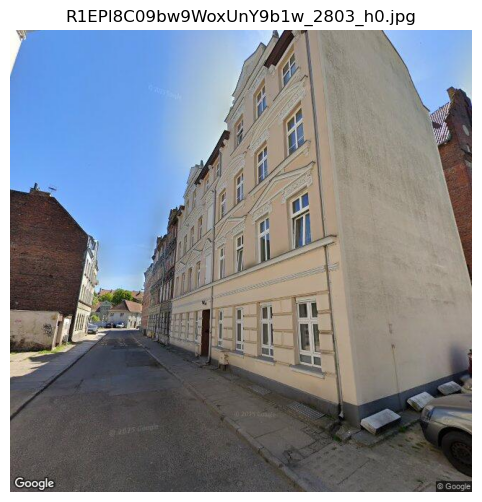

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/mnt/project/pt01183/openfacades_gsv_out/gsv_test_clean/R1EPl8C09bw9WoxUnY9b1w_2803_h0.jpg"

img = Image.open(img_path)
plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis("off")
plt.title(img_path.split("/")[-1])
plt.show()
